# Preamble

In [1]:
!date

Tue Apr  1 13:51:06 PDT 2025


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging

logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os

_os.chdir(_os.environ["PROJECT_ROOT"])

In [5]:
import os
from contextlib import contextmanager
from itertools import chain, product
from multiprocessing import Pool

import fastcluster
import graph_tool as gt
import graph_tool.draw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import strainzip as sz
import strainzip.app.unzip
import xarray as xr
from graph_tool.util import find_edge
from scipy.cluster.hierarchy import fcluster, linkage
from strainzip.pandas_util import idxwhere
from tqdm import tqdm

import lib.plot

# Params

## Plotting

In [150]:
mpl.rcParams["figure.dpi"] = 100
# sns.set_context('talk')

In [7]:
# Plotting parameters

length_bins = np.logspace(0, 6.5, num=51)
depth_bins = np.logspace(-1, 4, num=51)

linestyle_palette = {"megahit": ":", "strainzip": "-"}
facecolor_palette = {"megahit": "none", "strainzip": "auto"}

draw_graphs = True

## Project params

In [8]:
k = 111
group = "xjin_test6"  # "xjin_test6"  # "btheta_mixture1_cov10000"  # "btheta_mixture1_cov1000"
graph_type = f"k{k}-withmegahit3-droptips"
smoothing = "smoothed-6"
deconv = "norm-nobal-nocull-10-10"
marker_model_list = ["TIGR00952_1", "TIGR01063_1", "TIGR02013_1"]

In [9]:
# benchmark = "all_ref_tiles-k5000-o3000"
# benchmark = "all_ref_tiles-k10000-o5000"
# benchmark = "all_ref_tiles-k50000-o30000"
benchmark = "all_ref_cds"

coverage_thresh = 1.0

In [10]:
thresh_list = [
    ("0_identical", 1.0, coverage_thresh),
    ("1_veryhigh", 0.999, coverage_thresh),
    ("2_high", 0.995, coverage_thresh),
    ("3_medium", 0.99, coverage_thresh),
    ("4_verylow", 0.98, coverage_thresh),
]

# Load Data

## Load Metadata

In [11]:
mgen_group = (
    pd.read_table("meta/mgen_group.tsv")[lambda x: x.mgen_group == group]
    .assign(community_id=lambda x: x.mgen_id.str.split("_simcom_").str[0])
    .set_index("mgen_id")
)


mgen_group

,mgen_group,community_id
mgen_id,,
xjin_Flex_Innoculum_Rep1,xjin_test6,xjin_Flex_Innoculum_Rep1
xjin_KAPA_Innoculum_Rep1,xjin_test6,xjin_KAPA_Innoculum_Rep1
xjin_XT_Innoculum_Rep1,xjin_test6,xjin_XT_Innoculum_Rep1
xjin_AB_P0R1a,xjin_test6,xjin_AB_P0R1a
xjin_AS_P0R1a,xjin_test6,xjin_AS_P0R1a
...,...,...
xjin_AB_P5R2a,xjin_test6,xjin_AB_P5R2a
xjin_AS_P5R2a,xjin_test6,xjin_AS_P5R2a
xjin_MB_P5R2a,xjin_test6,xjin_MB_P5R2a


In [12]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov1000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov1000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov1000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov1000",
        "btheta_strainB_simcom_len150_seed0_cov1000",
    ],
    cm="coolwarm",
)
sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov10000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov10000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov10000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov10000",
        "btheta_strainB_simcom_len150_seed0_cov10000",
    ],
    cm="coolwarm",
    extend=sample_palette,
)

sample_palette = lib.plot.construct_ordered_palette(
    mgen_group.index, extend=sample_palette, cm="winter",
)

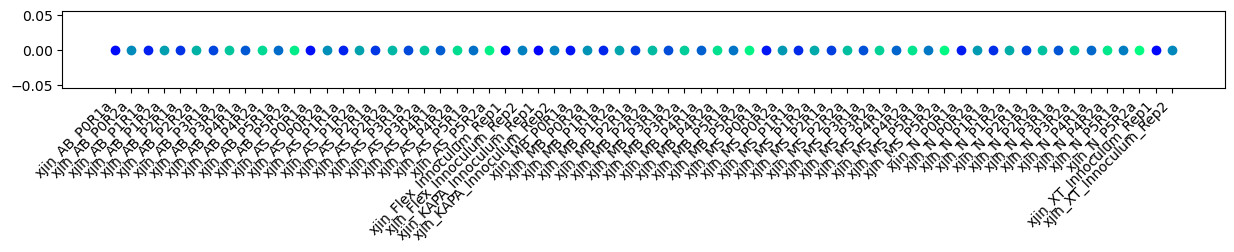

In [13]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

fig = plt.figure(figsize=(15, 1))
d = mgen_group.index.to_series().sort_values().map(sample_palette)#.rename('c').reset_index().assign(y=np.arange(len(mgen_group))).set_index('mgen_id')
for i, (m, c) in enumerate(d.items()):
    plt.scatter(i, 0, color=c)
plt.xticks(np.arange(len(d)), d.index)
lib.plot.rotate_xticklabels()

In [14]:
_genome = pd.read_table('meta/genome.tsv', index_col='genome_id')
genome_details = pd.read_table("meta/genome_group.tsv")[
    lambda x: x.genome_group_id == group
].assign(
    strain_id=lambda x: x.genome_id.str.rsplit("_").str[0],
    species_id=lambda x: x.genome_id.map(_genome.species_id),
)
genome_to_strain = genome_details.set_index("genome_id").strain_id
strain_to_genome = genome_details.set_index("strain_id").genome_id
genome_details = genome_details.set_index('genome_id')

In [15]:
if group.startswith("xjin"):
    kraken_read_counts = (
        pd.read_csv(
            "/pollard/home/xiaofanj/microbiomeAdhesion/intermediates/biofilmBeadExpV2/customKrakenOutputs/customKraken2BrackenAbundances.csv"
        )
        .set_index(["Strain_Name", "sample"])
        .new_est_reads.unstack("Strain_Name", fill_value=0)
        .rename(index=lambda x: "xjin_" + x)
    )
    known_rabund = kraken_read_counts.rename(columns=strain_to_genome).divide(
        kraken_read_counts.sum(1), axis=0
    ).loc[mgen_group.index]
elif group.startswith("btheta_mixture1"):
    sim_fractions = (
        pd.read_table("meta/simulated_community.tsv")[
            lambda x: x.community_id.isin(mgen_group.community_id)
        ]
        .set_index(["community_id", "genome_id"])
        .fraction.unstack(fill_value=0)
    )
    known_rabund = (
        mgen_group[["community_id"]]
        .join(sim_fractions, on="community_id")
        .drop(columns=["community_id"])
        .rename_axis(index="sample")
    )
else:
    assert False, "FIXME: This group type doesn't have a known_rabund..."

assert np.allclose(known_rabund.sum(1), 1)
known_rabund

Strain_Name,Acidaminococcus-fermentans-DSM-20731_MAF-2,Acidaminococcus-intestini-D21_MAF-2,Adlercreutzia-equolifaciens-DSM-19450_NCBI,Akkermansia-muciniphila-ATCC-BAA-835_MAF-2,Alistipes-finegoldii-DSM-17242_NCBI,Alistipes-ihumii-AP11_MAF-2,Alistipes-indistinctus-YIT-12060_MAF-2,Alistipes-onderdonkii-DSM-19147_MAF-2,Alistipes-putredinis-DSM-17216_MAF-2,Alistipes-senegalensis-JC50_MAF-2,...,Slackia-heliotrinireducens-DSM-20476_MAF-2,Solobacterium-moorei-DSM-22971_MAF-2,Streptococcus-thermophilus-LMD-9_MAF-2,Subdoligranulum-sp-4-3-54A2FAA_MAF-2,Subdoligranulum-variabile-DSM-15176_MAF-2,Turicibacter-sanguinis-DSM-14220_MAF-2,Tyzzerella-nexilis-DSM-1787_MAF-2,Veillonella-dispar-ATCC-17748_MAF-2,Veillonella-sp-3-1-44_MAF-2,Veillonella-sp-6-1-27_MAF-2
mgen_id,,,,,,,,,,,,,,,,,,,,,
xjin_Flex_Innoculum_Rep1,0.006343,0.004431,0.002981,1.166566e-03,0.003719,3.026672e-06,1.111437e-03,0.003343,5.683658e-04,9.339014e-03,...,0.001432,0.058781,5.227496e-04,0.005493,4.404889e-03,1.945718e-06,9.392197e-03,2.243197e-03,7.857241e-03,3.827227e-03
xjin_KAPA_Innoculum_Rep1,0.005739,0.004260,0.002788,1.092183e-03,0.003605,2.983088e-06,1.050979e-03,0.003066,5.626850e-04,8.917756e-03,...,0.001273,0.063503,5.347186e-04,0.005110,3.899083e-03,2.237316e-06,9.644511e-03,2.261740e-03,7.956083e-03,3.865896e-03
xjin_XT_Innoculum_Rep1,0.006513,0.004802,0.003092,1.151555e-03,0.003624,2.208034e-06,1.104277e-03,0.003258,5.816221e-04,9.333619e-03,...,0.001525,0.059233,4.905732e-04,0.005951,4.560499e-03,2.337918e-06,8.089587e-03,2.227517e-03,7.703311e-03,3.686118e-03
xjin_AB_P0R1a,0.097499,0.033541,0.000017,1.714562e-05,0.000523,1.329118e-07,1.860765e-06,0.000040,4.651913e-07,9.343699e-05,...,0.000017,0.002550,8.571482e-04,0.000439,2.259501e-06,6.645590e-08,3.010452e-04,2.104592e-03,2.530448e-02,3.988550e-03
xjin_AS_P0R1a,0.083566,0.099740,0.000081,6.002932e-05,0.001388,4.887055e-07,1.278779e-05,0.000210,1.629018e-06,8.079931e-05,...,0.000197,0.001560,5.429518e-04,0.000910,2.850782e-06,5.701564e-07,2.997394e-05,5.747991e-04,4.928668e-02,1.158224e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xjin_AB_P5R2a,0.038757,0.099266,0.000000,2.569630e-05,0.000416,2.314982e-07,0.000000e+00,0.000050,5.787455e-07,1.157491e-07,...,0.000000,0.000260,2.314982e-07,0.000023,9.259928e-07,0.000000e+00,7.292193e-06,1.041742e-06,5.613831e-05,1.041742e-06
xjin_AS_P5R2a,0.026126,0.193207,0.000000,1.890933e-04,0.001520,8.012427e-08,0.000000e+00,0.000216,9.614912e-07,5.608699e-07,...,0.000000,0.000697,0.000000e+00,0.000163,1.522361e-06,0.000000e+00,6.009320e-06,0.000000e+00,5.408388e-05,8.012427e-08
xjin_MB_P5R2a,0.005023,0.152109,0.000000,7.905201e-07,0.000452,1.317534e-07,0.000000e+00,0.006851,6.587668e-07,1.449287e-06,...,0.000000,0.000780,0.000000e+00,0.000194,8.166073e-04,6.587668e-08,2.734541e-04,0.000000e+00,1.976300e-07,0.000000e+00


## Depth

### StrainZip

In [16]:
final_graph = sz.io.load_graph(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.sz"
)

vertex_depth = (
    sz.results.depth_table(final_graph, final_graph.get_vertices())
    .T.rename_axis(index="vertex", columns="sample")
    .rename(columns=mgen_group.index.to_series().reset_index(drop=True))
)
vertex_depth

sample,xjin_Flex_Innoculum_Rep1,xjin_KAPA_Innoculum_Rep1,xjin_XT_Innoculum_Rep1,xjin_AB_P0R1a,xjin_AS_P0R1a,xjin_MB_P0R1a,xjin_MS_P0R1a,xjin_N_P0R1a,xjin_AB_P1R1a,xjin_AS_P1R1a,...,xjin_AB_P4R2a,xjin_AS_P4R2a,xjin_MB_P4R2a,xjin_MS_P4R2a,xjin_N_P4R2a,xjin_AB_P5R2a,xjin_AS_P5R2a,xjin_MB_P5R2a,xjin_MS_P5R2a,xjin_N_P5R2a
vertex,,,,,,,,,,,,,,,,,,,,,
0,0.961485,2.363849e+00,3.140744e-01,19.088191,65.862521,35.220101,52.319935,134.330090,24.153705,119.728287,...,23.131578,141.173919,53.547805,122.081141,145.510038,34.915313,99.944644,98.335691,162.137387,152.080599
1,0.904131,2.451682e+00,2.881409e-02,18.915795,67.992065,35.468240,52.795275,135.693239,24.018064,122.377602,...,22.702924,140.749132,54.310165,122.075911,145.637820,34.430325,101.635510,98.987795,163.541673,153.554052
2,6.515788,1.152031e+01,1.576318e+01,177.537176,14.693888,100.908870,56.168074,4.776498,459.668169,96.114557,...,774.416276,52.948376,138.347651,9.240571,35.414222,401.004815,53.396595,336.344675,36.603341,34.044340
3,0.000001,5.860089e-08,1.491790e-09,0.419653,0.000005,0.322658,0.000020,0.000005,3.184117,0.000058,...,2.706908,0.000026,0.000050,0.000005,0.000022,0.142750,0.000030,0.699913,0.000022,0.000024
4,0.696113,1.710292e+00,1.215130e+00,5.568148,35.784155,19.743075,32.007688,66.182707,9.561913,61.609137,...,11.019106,68.937382,25.159381,54.502944,61.551535,17.277910,54.680529,51.486343,61.195690,91.883817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727964,0.317701,2.758441e-01,3.154402e-01,0.029703,0.028131,0.002725,0.044289,0.156581,0.000259,0.000258,...,0.000258,0.000258,0.011783,0.000259,0.000258,0.000258,0.000258,0.000773,0.013946,0.000258
727965,0.001043,1.042414e-03,1.030904e-03,0.001047,0.001046,0.001047,0.001045,0.001046,0.001047,0.001046,...,0.001046,0.001046,0.001046,0.001046,0.001046,0.001046,0.001046,0.001046,0.001046,0.001046
727966,0.000796,8.545338e-04,7.907756e-04,0.000935,0.000933,0.000935,0.000933,0.000933,0.000935,0.000933,...,0.000933,0.000933,0.000933,0.000933,0.000933,0.000933,0.000933,0.000933,0.000933,0.000933


### MEGAHIT/Bowtie2

In [17]:
megahit_gene_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.gene_depth.tsv",
    names=["sample", "gene", "depth"],
    index_col=["sample", "gene"],
).depth.unstack("sample", fill_value=0)

In [18]:
megahit_contig_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.contig_depth.tsv",
    names=["sample", "contig", "depth"],
    index_col=["sample", "contig"],
).depth.unstack("sample", fill_value=0)

## Genes

### StrainZip

In [19]:
strainzip_gene = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
strainzip_gene

,vertex,left,right,gene,score,strand
0,0,0,111,0[0-111]+,0,+
1,1,2,113,1[2-113]+,0,+
2,10,2,110,10[2-110]-,0,-
3,100,0,69,100[0-69]-,0,-
4,1000,1,652,1000[1-652]+,0,+
...,...,...,...,...,...,...
1997655,99995,1,109,99995[1-109]+,0,+
1997656,99996,0,111,99996[0-111]-,0,-
1997657,99997,2,113,99997[2-113]-,0,-
1997658,99998,2,110,99998[2-110]+,0,+


#### Depth Markers

In [20]:
total_strainzip_marker_depth = {}

for marker_model in marker_model_list:
    strainzip_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    # print(strainzip_marker_gene_list)

    total_strainzip_marker_depth[marker_model] = vertex_depth.loc[
        strainzip_gene[lambda x: x.gene.isin(strainzip_marker_gene_list)].vertex
    ].sum()

total_strainzip_marker_depth = pd.DataFrame(total_strainzip_marker_depth)
print(total_strainzip_marker_depth)

total_strainzip_marker_depth = total_strainzip_marker_depth.mean(1)
print(total_strainzip_marker_depth)

                          TIGR00952_1  TIGR01063_1  TIGR02013_1
sample                                                         
xjin_Flex_Innoculum_Rep1   139.508239   132.759261   137.621290
xjin_KAPA_Innoculum_Rep1   173.321584   169.474559   174.936909
xjin_XT_Innoculum_Rep1     204.655756   191.252637   215.993492
xjin_AB_P0R1a              354.786007   326.175878   351.817526
xjin_AS_P0R1a              463.375925   287.113543   340.755397
...                               ...          ...          ...
xjin_AB_P5R2a              248.706050   168.809510   211.113788
xjin_AS_P5R2a              456.294251   199.121615   232.491541
xjin_MB_P5R2a              512.238018   281.943905   344.394946
xjin_MS_P5R2a              568.771132   251.988797   311.378994
xjin_N_P5R2a               575.541221   165.130000   227.955065

[66 rows x 3 columns]
sample
xjin_Flex_Innoculum_Rep1    136.629596
xjin_KAPA_Innoculum_Rep1    172.577684
xjin_XT_Innoculum_Rep1      203.967295
xjin_AB_P0R1a        

In [21]:
strainzip_normalized_depth = (vertex_depth / total_strainzip_marker_depth).T
strainzip_normalized_depth

vertex,0,1,2,3,4,5,6,7,8,9,...,727959,727960,727961,727962,727963,727964,727965,727966,727967,727968
sample,,,,,,,,,,,,,,,,,,,,,
xjin_Flex_Innoculum_Rep1,0.007037,0.006617,0.047689,7.803178e-09,0.005095,0.003543,7.451690e-11,0.005626,4.345294e-08,0.007800,...,7.355514e-05,8.744006e-07,2.385023e-06,6.436106e-05,0.000956,2.325275e-03,0.000008,0.000006,0.000003,2.713886e-06
xjin_KAPA_Innoculum_Rep1,0.013697,0.014206,0.066754,3.395624e-10,0.009910,0.001709,2.276940e-12,0.005623,1.689121e-11,0.010333,...,1.003426e-04,9.440075e-07,8.589917e-04,6.027776e-04,0.000588,1.598376e-03,0.000006,0.000005,0.000005,1.790811e-06
xjin_XT_Innoculum_Rep1,0.001540,0.000141,0.077283,7.313870e-12,0.005957,0.004036,8.621208e-10,0.003971,8.563939e-12,0.002665,...,4.924349e-05,7.922809e-07,7.625108e-04,2.108043e-04,0.001598,1.546523e-03,0.000005,0.000004,0.000007,1.812141e-06
xjin_AB_P0R1a,0.055447,0.054946,0.515707,1.219002e-03,0.016174,0.035247,2.847228e-07,0.038540,6.650125e-07,0.024592,...,4.411000e-05,9.883979e-07,9.825847e-06,1.018045e-05,0.000001,8.628221e-05,0.000003,0.000003,0.000002,1.831224e-06
xjin_AS_P0R1a,0.181066,0.186921,0.040396,1.261102e-08,0.098376,0.146342,4.229436e-07,0.082906,1.036774e-06,0.089906,...,6.187225e-05,9.352664e-07,1.166055e-04,2.841142e-05,0.000451,7.733557e-05,0.000003,0.000003,0.000002,9.762993e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xjin_AB_P5R2a,0.166626,0.164311,1.913710,6.812430e-04,0.082455,0.146893,4.093476e-07,0.083806,1.895449e-06,0.126865,...,2.380354e-06,1.623544e-06,1.113259e-06,1.091986e-06,0.000002,1.233175e-06,0.000005,0.000004,0.000003,2.436223e-06
xjin_AS_P5R2a,0.337686,0.343399,0.180413,1.003812e-07,0.184751,0.352515,2.423062e-03,0.162865,2.567594e-03,0.133268,...,6.264343e-05,1.149458e-06,1.527830e-06,7.731147e-07,0.000001,8.730762e-07,0.000004,0.000003,0.000002,1.739690e-06
xjin_MB_P5R2a,0.259102,0.260820,0.886224,1.844178e-03,0.135660,0.260526,1.542718e-03,0.134092,8.164381e-04,0.131904,...,2.598296e-04,5.610343e-07,8.663935e-07,1.776273e-06,0.000003,2.035498e-06,0.000003,0.000002,0.000002,1.353586e-06


### MEGAHIT/Bowtie2

In [22]:
megahit_gene = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
megahit_gene

,vertex,left,right,gene,score,strand
0,k111_0,1,325,k111_0[1-325]+,0,+
1,k111_100,0,321,k111_100[0-321]+,0,+
2,k111_1000,1,295,k111_1000[1-295]-,0,-
3,k111_10001,0,294,k111_10001[0-294]-,0,-
4,k111_10001,388,472,k111_10001[388-472]+,0,+
...,...,...,...,...,...,...
373515,k111_9999,384,729,k111_9999[384-729]-,0,-
373516,k111_9999,890,1337,k111_9999[890-1337]+,0,+
373517,k111_9999,1478,1655,k111_9999[1478-1655]+,0,+
373518,k111_9999,1731,2433,k111_9999[1731-2433]-,0,-


#### Depth Markers

In [23]:
total_megahit_marker_depth = {}

for marker_model in marker_model_list:
    megahit_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    total_megahit_marker_depth[marker_model] = megahit_gene_depth.loc[
        megahit_gene[lambda x: x.gene.isin(megahit_marker_gene_list)].gene
    ].sum()

total_megahit_marker_depth = pd.DataFrame(total_megahit_marker_depth)
print(total_megahit_marker_depth)

total_megahit_marker_depth = total_megahit_marker_depth.mean(1)
print(total_megahit_marker_depth)

                        TIGR00952_1  TIGR01063_1  TIGR02013_1
sample                                                       
xjin_AB_P0R1a            658.131504   999.113266  1005.184346
xjin_AB_P0R2a            600.893467   833.028290   822.956888
xjin_AB_P1R1a            598.354286   829.142451   880.461051
xjin_AB_P1R2a            684.882505   832.456110   929.591059
xjin_AB_P2R1a            507.672952   594.849127   670.703337
...                             ...          ...          ...
xjin_N_P4R2a             716.874417   811.638979   852.975639
xjin_N_P5R1a             770.344437   897.972046  1004.495723
xjin_N_P5R2a             680.309510   856.421344   902.985585
xjin_XT_Innoculum_Rep1   343.425142   572.397449   607.627143
xjin_XT_Innoculum_Rep2   175.592714   190.031263   204.039728

[66 rows x 3 columns]
sample
xjin_AB_P0R1a             887.476372
xjin_AB_P0R2a             752.292882
xjin_AB_P1R1a             769.319263
xjin_AB_P1R2a             815.643225
xjin_AB_P2R1a   

In [24]:
megahit_normalized_depth = (megahit_contig_depth / total_megahit_marker_depth).T
megahit_normalized_depth

contig,k111_0,k111_100,k111_1000,k111_10001,k111_10003,k111_10004,k111_10005,k111_10006,k111_10008,k111_10009,...,k111_9990,k111_9991,k111_9992,k111_9993,k111_9994,k111_9995,k111_9996,k111_9997,k111_9998,k111_9999
sample,,,,,,,,,,,,,,,,,,,,,
xjin_AB_P0R1a,0.001463,0.002394,0.000000,0.001391,0.00000,0.000121,0.0,0.000000,0.004346,0.001435,...,0.016506,0.000000,0.000000,0.000000,0.000000,0.000322,0.001545,0.002555,0.000000,0.022261
xjin_AB_P0R2a,0.001791,0.002418,0.000000,0.000821,0.00000,0.000017,0.0,0.000000,0.006156,0.001842,...,0.013075,0.000000,0.000000,0.000000,0.000000,0.000440,0.000000,0.002161,0.000000,0.016680
xjin_AB_P1R1a,0.001544,0.003750,0.000000,0.003202,0.00000,0.000469,0.0,0.000000,0.001211,0.000881,...,0.012474,0.000000,0.000000,0.000000,0.000000,0.000120,0.000891,0.000000,0.000000,0.035467
xjin_AB_P1R2a,0.001102,0.001673,0.000000,0.003027,0.00000,0.004572,0.0,0.000000,0.000107,0.000985,...,0.010336,0.000000,0.000000,0.000000,0.000000,0.000009,0.000840,0.000795,0.000000,0.042961
xjin_AB_P2R1a,0.000000,0.000000,0.000000,0.003756,0.00000,0.001141,0.0,0.000000,0.000315,0.000143,...,0.016884,0.000000,0.000000,0.000000,0.000000,0.000310,0.000000,0.001824,0.000000,0.010828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xjin_N_P4R2a,0.001128,0.000000,0.000000,0.000844,0.00000,0.000000,0.0,0.000000,0.000103,0.001612,...,0.020937,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000819,0.000000,0.003165
xjin_N_P5R1a,0.000504,0.000000,0.000000,0.000674,0.00000,0.000204,0.0,0.000000,0.001300,0.000000,...,0.021502,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002592,0.000000,0.004666
xjin_N_P5R2a,0.000552,0.000000,0.000000,0.000759,0.00000,0.000000,0.0,0.000000,0.000267,0.000155,...,0.028605,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003106,0.000000,0.003931


# Sequence Matching

## BLASTn

In [25]:
benchmark_sequence_length = pd.read_table(
    f"data/group/{group}/{benchmark}.benchmark_sequences.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0-1389]+       1389
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[1636-2764]+    1128
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[2763-3900]+    1137
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[3896-4628]+     732
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[4605-4833]+     228
                                                            ... 
Veillonella-sp-6-1-27_MAF-2_1[2178221-2179019]-              798
Veillonella-sp-6-1-27_MAF-2_1[2179028-2179694]-              666
Veillonella-sp-6-1-27_MAF-2_1[2179856-2180078]-              222
Veillonella-sp-6-1-27_MAF-2_1[2180126-2180492]-              366
Veillonella-sp-6-1-27_MAF-2_1[2180565-2180700]-              135
Name: nlength, Length: 410946, dtype: int64

In [26]:
bench_to_genome = benchmark_sequence_length.index.to_series().str.rsplit('_', n=1).str[0].rename('genome')
bench_to_genome

gene
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0-1389]+       Acidaminococcus-fermentans-DSM-20731_MAF-2
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[1636-2764]+    Acidaminococcus-fermentans-DSM-20731_MAF-2
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[2763-3900]+    Acidaminococcus-fermentans-DSM-20731_MAF-2
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[3896-4628]+    Acidaminococcus-fermentans-DSM-20731_MAF-2
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[4605-4833]+    Acidaminococcus-fermentans-DSM-20731_MAF-2
                                                                               ...                    
Veillonella-sp-6-1-27_MAF-2_1[2178221-2179019]-                            Veillonella-sp-6-1-27_MAF-2
Veillonella-sp-6-1-27_MAF-2_1[2179028-2179694]-                            Veillonella-sp-6-1-27_MAF-2
Veillonella-sp-6-1-27_MAF-2_1[2179856-2180078]-                            Veillonella-sp-6-1-27_MAF-2
Veillonella-sp-6-1-27_MAF-2_1[2180126-2180492]-                     

In [27]:
blastn_columns = [
    # Thanks ChatGPT.
    "qseqid",  # Query sequence ID
    "sseqid",  # Subject sequence ID
    "pident",  # Percentage of identical matches
    "length",  # Alignment length
    "mismatch",  # Number of mismatches
    "gapopen",  # Number of gap openings
    "qstart",  # Start of alignment in query
    "qend",  # End of alignment in query
    "sstart",  # Start of alignment in subject
    "send",  # End of alignment in subject
    "evalue",  # Expect value
    "bitscore",  # Bit score
]

### Ref

In [28]:
match_ref = (
    pd.read_table(
        f"data/group/{group}/all_refs.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        genome=lambda x: x.sseqid.str.rsplit("_", n=1).str[
            0
        ],  # Equivalent to the "vertex" field for the strainzip_match and megahit_match tables. I'll join depths based on this.
    )
)

match_ref

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,genome
0,Acidaminococcus-intestini-D21_MAF-2_1[2161752-...,Acidaminococcus-intestini-D21_MAF-2_1,100.000,393,0,0,1,393,2162145,2161753,0.000000e+00,726.0,393,1.00000,1.000000,0,2162144,393,2161753,Acidaminococcus-intestini-D21_MAF-2
1,Acidaminococcus-intestini-D21_MAF-2_1[2161752-...,Acidaminococcus-fermentans-DSM-20731_MAF-2_1,88.325,394,44,2,1,393,2123258,2122866,1.390000e-131,472.0,393,0.88325,1.002545,0,2123257,393,2122866,Acidaminococcus-fermentans-DSM-20731_MAF-2
2,Acidaminococcus-intestini-D21_MAF-2_1[2161752-...,Megasphaera-DSMZ-102144_MinIONHybrid_1,80.112,357,57,12,45,393,1125160,1125510,5.470000e-66,254.0,393,0.80112,0.908397,44,1125159,393,1125510,Megasphaera-DSMZ-102144_MinIONHybrid
3,Acidaminococcus-intestini-D21_MAF-2_1[2162166-...,Acidaminococcus-intestini-D21_MAF-2_1,100.000,366,0,0,1,366,2162532,2162167,0.000000e+00,676.0,366,1.00000,1.000000,0,2162531,366,2162167,Acidaminococcus-intestini-D21_MAF-2
4,Acidaminococcus-intestini-D21_MAF-2_1[2162166-...,Acidaminococcus-fermentans-DSM-20731_MAF-2_1,85.470,351,50,1,1,351,2123649,2123300,2.240000e-99,364.0,366,0.85470,0.959016,0,2123648,351,2123300,Acidaminococcus-fermentans-DSM-20731_MAF-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540136,Tyzzerella-nexilis-DSM-1787_MAF-2_1[3440366-34...,Blautia-hansenii-DSM-20583_MAF-2_1,74.495,1486,330,43,456,1914,2902272,2900809,3.140000e-169,599.0,1914,0.74495,0.776385,455,2902271,1914,2900809,Blautia-hansenii-DSM-20583_MAF-2
1540137,Tyzzerella-nexilis-DSM-1787_MAF-2_1[3442375-34...,Tyzzerella-nexilis-DSM-1787_MAF-2_1,100.000,2514,0,0,1,2514,3444889,3442376,0.000000e+00,4643.0,2514,1.00000,1.000000,0,3444888,2514,3442376,Tyzzerella-nexilis-DSM-1787_MAF-2
1540138,Tyzzerella-nexilis-DSM-1787_MAF-2_1[3442375-34...,Tyzzerella-nexilis-DSM-1787_MAF-2_1,87.234,141,17,1,817,957,3444001,3443862,8.320000e-37,159.0,2514,0.87234,0.056086,816,3444000,957,3443862,Tyzzerella-nexilis-DSM-1787_MAF-2
1540139,Tyzzerella-nexilis-DSM-1787_MAF-2_1[3442375-34...,Tyzzerella-nexilis-DSM-1787_MAF-2_1,87.234,141,17,1,889,1028,3444073,3443933,8.320000e-37,159.0,2514,0.87234,0.056086,888,3444072,1028,3443933,Tyzzerella-nexilis-DSM-1787_MAF-2


### StrainZip

In [29]:
match_strainzip = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_strainzip  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,676048,100.000,1389,0,0,1,1389,51019,52407,0.000000,2566.0,1389,1.00000,1.000000,0,51018,1389,52407,676048
1,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,678427,100.000,1389,0,0,1,1389,21845,20457,0.000000,2566.0,1389,1.00000,1.000000,0,21844,1389,20457,678427
2,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,672108,100.000,1389,0,0,1,1389,51019,52407,0.000000,2566.0,1389,1.00000,1.000000,0,51018,1389,52407,672108
3,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,671582,100.000,1389,0,0,1,1389,21996,20608,0.000000,2566.0,1389,1.00000,1.000000,0,21995,1389,20608,671582
4,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,711485,97.143,35,1,0,665,699,28508,28542,0.000002,60.2,1389,0.97143,0.025198,664,28507,699,28542,711485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080660,Veillonella-sp-6-1-27_MAF-2_1[2024013-2024400]-,700330,100.000,387,0,0,1,387,19820,20206,0.000000,715.0,387,1.00000,1.000000,0,19819,387,20206,700330
7080661,Veillonella-sp-6-1-27_MAF-2_1[2024013-2024400]-,697448,99.483,387,2,0,1,387,14508,14122,0.000000,704.0,387,0.99483,1.000000,0,14507,387,14122,697448
7080662,Veillonella-sp-6-1-27_MAF-2_1[2024013-2024400]-,697549,99.483,387,2,0,1,387,14152,14538,0.000000,704.0,387,0.99483,1.000000,0,14151,387,14538,697549
7080663,Veillonella-sp-6-1-27_MAF-2_1[2024013-2024400]-,696693,99.483,387,2,0,1,387,14152,14538,0.000000,704.0,387,0.99483,1.000000,0,14151,387,14538,696693


### MEGAHIT

In [30]:
match_megahit = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_megahit  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,k111_83749,100.000,1389,0,0,1,1389,11623,13011,0.000000e+00,2566.0,1389,1.00000,1.000000,0,11622,1389,13011,k111_83749
1,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0...,k111_55046,97.143,35,1,0,665,699,28125,28159,3.700000e-07,60.2,1389,0.97143,0.025198,664,28124,699,28159,k111_55046
2,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[1...,k111_83749,100.000,1128,0,0,1,1128,13259,14386,0.000000e+00,2084.0,1128,1.00000,1.000000,0,13258,1128,14386,k111_83749
3,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[2...,k111_83749,100.000,1137,0,0,1,1137,14386,15522,0.000000e+00,2100.0,1137,1.00000,1.000000,0,14385,1137,15522,k111_83749
4,Acidaminococcus-fermentans-DSM-20731_MAF-2_1[3...,k111_83749,100.000,732,0,0,1,732,15519,16250,0.000000e+00,1352.0,732,1.00000,1.000000,0,15518,732,16250,k111_83749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180068,Veillonella-sp-6-1-27_MAF-2_1[2022936-2023281]-,k111_10039,92.754,345,25,0,1,345,20864,20520,4.310000e-140,499.0,345,0.92754,1.000000,0,20863,345,20520,k111_10039
1180069,Veillonella-sp-6-1-27_MAF-2_1[2023507-2023609]-,k111_59624,100.000,102,0,0,1,102,443,544,2.560000e-47,189.0,102,1.00000,1.000000,0,442,102,544,k111_59624
1180070,Veillonella-sp-6-1-27_MAF-2_1[2023507-2023609]-,k111_83349,98.039,102,2,0,1,102,65489,65590,5.540000e-44,178.0,102,0.98039,1.000000,0,65488,102,65590,k111_83349
1180071,Veillonella-sp-6-1-27_MAF-2_1[2024013-2024400]-,k111_83349,99.483,387,2,0,1,387,64649,65035,0.000000e+00,704.0,387,0.99483,1.000000,0,64648,387,65035,k111_83349


# Depth Estimation

## Effect of matching threshold

In [31]:
def predict_depth_from_match_and_weight(match, weight, selector):
    dictionary = match[selector][["key", "qseqid"]].value_counts().unstack("key")
    a, b = weight.align(dictionary, join="inner", axis="columns", fill_value=0)
    return a @ b.fillna(0).T

In [32]:
def predict_depth_from_match_and_weight2(match, weight, selector):
    idx_to_qseqid = pd.Series(match.qseqid.unique(), name="qseqid").rename_axis("idx")
    qseqid_to_idx = idx_to_qseqid.reset_index().set_index("qseqid").squeeze()
    idx_to_key = pd.Series(match.key.unique(), name="key").rename_axis("idx")
    key_to_idx = idx_to_key.reset_index().set_index("key").squeeze()

    dictionary = sp.sparse.csc_array(
        (selector(match), (match.qseqid.map(qseqid_to_idx), match.key.map(key_to_idx)))
    )
    # NOTE: I'm doing manual index alignment here. This part is tricky and prone to hard-to-find errors.
    result = pd.DataFrame(
        dictionary @ weight.reindex(columns=idx_to_key.sort_index().values, fill_value=0).T,
        columns=weight.index,
    ).rename(index=idx_to_qseqid, columns=idx_to_key)
    return result


# r = predict_depth_from_match_and_weight2(
#     match_strainzip.rename(columns=dict(vertex="key")),
#     _normalized_vertex_depth.T,
#     selector,
# )

In [33]:
def sparse_matrix_encode(pairs):
    stacked = pd.Index(pairs, name=('row', 'col')).to_frame().assign(val=1)
    row_key_for_idx_mapping = pd.Series(stacked.row.unique()).rename_axis('idx').rename('key').reset_index()
    col_key_for_idx_mapping = pd.Series(stacked.col.unique()).rename_axis('idx').rename('key').reset_index()

    sparse = sp.sparse.csc_array(
        (stacked.val.values, stacked.row.map(row_key_for_idx_mapping.set_index('key').idx), stacked.col.map(col_key_for_idx_mapping.set_index('key').idx))
    )
    return sparse, (row_key_for_idx_mapping.set_index('idx').key, col_key_for_idx_mapping.set_index('idx').key)

sparse_matrix_encode([(1, 1), (1, 'who'), ('this', 'who')])

(<Compressed Sparse Column sparse array of dtype 'int64'
 	with 1 stored elements and shape (2, 2)>,
 (idx
  0       1
  1    this
  Name: key, dtype: object,
  idx
  0      1
  1    who
  Name: key, dtype: object))

In [34]:
def predict_depth_from_match_and_weight3(match, weight, selector):
    match = match[selector]
    dictionary, (idx_to_qseqid, idx_to_key) = sparse_matrix_encode(zip(match.qseqid, match.key))
    # NOTE: I'm doing manual index alignment here. This part is tricky and prone to hard-to-find errors.
    result = pd.DataFrame(
        dictionary @ weight.reindex(columns=idx_to_key.sort_index().values, fill_value=0).T,
        columns=weight.index,
    ).rename(index=idx_to_qseqid, columns=idx_to_key)
    return result

In [35]:
# error_result = {}
estimate_result = {}

tool_match_weight_list = [
    (
        "expect",
        match_ref.assign(key=lambda x: x.genome),
        known_rabund
    ),
    (
        "strainzip",
        match_strainzip.assign(key=lambda x: x.vertex),
        strainzip_normalized_depth,
    ),
    (
        "megahit",
        match_megahit.assign(key=lambda x: x.vertex),
        megahit_normalized_depth,
    ),
]


with tqdm(total=len(tool_match_weight_list) * len(thresh_list)) as pbar:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )

        if match_ref[_selector].empty:
            print("No reference sequences match the selector.")
            continue

        # _ref_pred = predict_depth_from_match_and_weight2(
        #     match=match_ref.assign(key=lambda x: x.genome),
        #     weight=known_rabund,
        #     selector=_selector,
        # )
        # estimate_result[('expected', thresh_name, _min_identity, _min_coverage)] = _ref_pred.rename_axis('bench')

        for tool_name, match, weight in tool_match_weight_list:
            _tool_pred = predict_depth_from_match_and_weight2(
                match=match,
                weight=weight,
                selector=_selector,
            )

            estimate_result[(tool_name, thresh_name)] = _tool_pred.rename_axis(index='bench', columns='sample')
            pbar.update()
            
#             x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)
#             d0 = pd.DataFrame(
#                 dict(
#                     expected=x0.rename_axis(index="bench").stack().values,
#                     estimated=y0.rename_axis(index="bench").stack().values,
#                 ),
#                 index=x0.rename_axis(index="bench").stack().index,
#             ).assign(
#                 abs_resid=lambda x: np.abs(x.estimated - x.expected),
#                 sqr_resid=lambda x: np.square(x.estimated - x.expected),
#                 sqr_expect=lambda x: np.square(x.expected),
#             )

#             error_result[(thresh_name, min_coverage, min_identity, tool_name)] = (
#                 pd.DataFrame(
#                     dict(
#                         mean_abs_residual_bench_depth=(
#                             d0.abs_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_residual_bench_depth=(
#                             d0.sqr_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_expected_bench_depth=(
#                             d0.expected.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_expected_bench_depth=(
#                             d0.sqr_expect.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                     )
#                 )
#             )
#             pbar.update()

estimate_result = pd.concat(
    estimate_result, names=["tool", "thresh"]
).stack().to_xarray().fillna(0)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:56<00:00,  3.77s/it]


<Axes: xlabel='None-thresh', ylabel='tool-bench'>

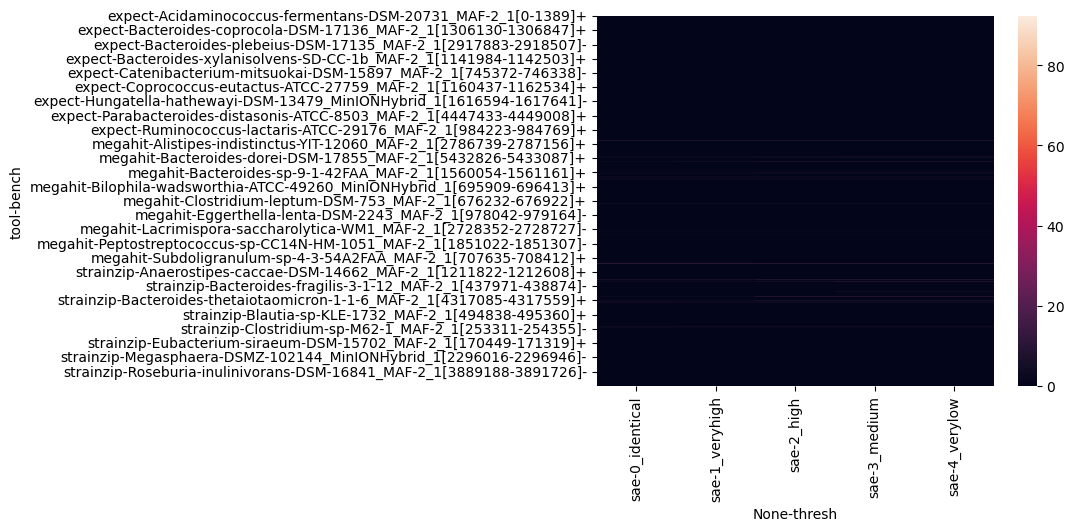

In [36]:
error_result = estimate_result - estimate_result.sel(tool='expect')

d = error_result.pipe(abs).sum("sample").to_dataframe(name='sae').unstack('thresh')
sns.heatmap(d)

In [37]:
benchmark_sequence_length

gene
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0-1389]+       1389
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[1636-2764]+    1128
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[2763-3900]+    1137
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[3896-4628]+     732
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[4605-4833]+     228
                                                            ... 
Veillonella-sp-6-1-27_MAF-2_1[2178221-2179019]-              798
Veillonella-sp-6-1-27_MAF-2_1[2179028-2179694]-              666
Veillonella-sp-6-1-27_MAF-2_1[2179856-2180078]-              222
Veillonella-sp-6-1-27_MAF-2_1[2180126-2180492]-              366
Veillonella-sp-6-1-27_MAF-2_1[2180565-2180700]-              135
Name: nlength, Length: 410946, dtype: int64

In [38]:
_bench_depth_total = estimate_result.transpose('tool', 'thresh', 'sample', 'bench') * benchmark_sequence_length.rename_axis('bench').to_xarray()
_bench_depth_true = _bench_depth_total.sel(tool='expect')
_bench_depth_error = _bench_depth_total.sel(tool=['megahit', 'strainzip']) - _bench_depth_true

In [39]:
_bench_depth_abs_error = _bench_depth_error.pipe(np.abs)
_bench_to_genome_operator = bench_to_genome.rename_axis('bench').reset_index().assign(val=1).set_index(['bench', 'genome']).val.to_xarray().fillna(0)
_per_genome_bench_depth_abs_error = _bench_depth_abs_error @ _bench_to_genome_operator
_per_genome_bench_depth_total = _bench_depth_true @ _bench_to_genome_operator

_per_genome_bench_depth_normalized_absolute_error = _per_genome_bench_depth_abs_error.sum("sample") / _per_genome_bench_depth_total.sum("sample")

<Axes: xlabel='thresh', ylabel='tool-genome'>

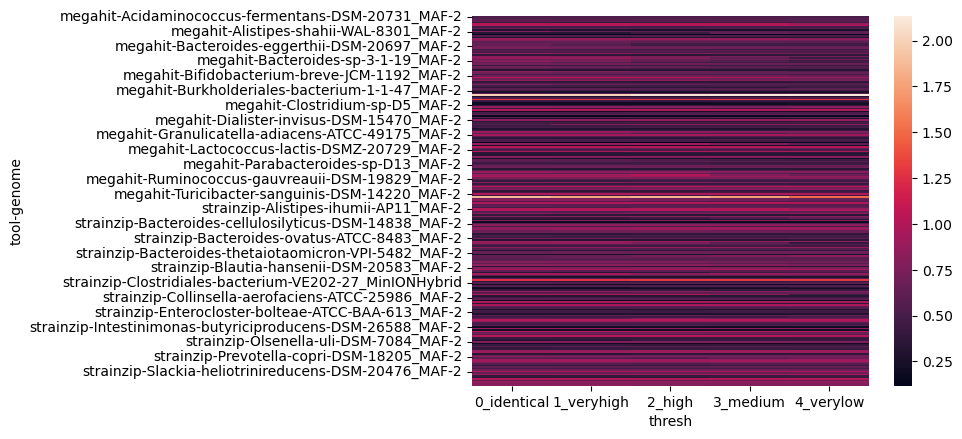

In [40]:
d = _per_genome_bench_depth_normalized_absolute_error.to_series().unstack('thresh')
sns.heatmap(d)

In [215]:
# WORKHERE

thresh = '0_identical'
# Only consider genomes where the species has multiple strains.
genome_id_list = idxwhere(genome_details.species_id.isin(idxwhere(genome_details.species_id.value_counts().drop('UNKNOWN') > 1))).to_series().str.replace('-', '_').values

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))

d0 = _per_genome_bench_depth_normalized_absolute_error.sel(thresh=thresh).to_series().unstack('tool').rename_axis(index='genome_id').rename(lambda x: x.replace('-', '_')).assign(mean_rabund=_mean_rabund)

d0.drop(genome_id_list).to_csv('fig/normalized_absolute_error_id100_hcom2_singlestrain.tsv', sep='\t')
d0.loc[genome_id_list].to_csv('fig/normalized_absolute_error_id100_hcom2_multistrain.tsv', sep='\t')

/tmp/bsmith/ipykernel_1837288/3791881750.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(d.drop(genome_id_list).megahit, d.drop(genome_id_list).strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)
/tmp/bsmith/ipykernel_1837288/3791881750.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(d.loc[genome_id_list].megahit, d.loc[genome_id_list].strainzip, color='tab:orange', norm=mpl.colors.PowerNorm(1/3))


Text(0.5, 1.0, 'Normalized Error')

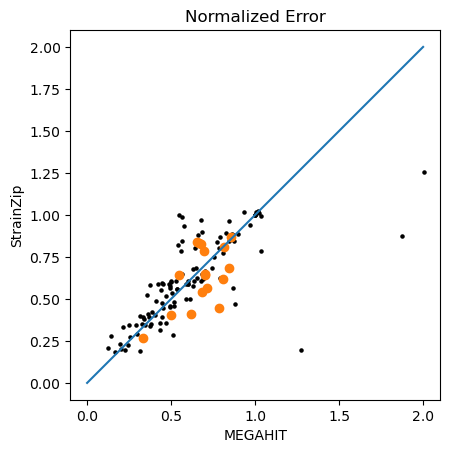

In [189]:
# c = _per_genome_bench_depth_total.sum('sample').sel(thresh=thresh)

d = d0

fig, ax = plt.subplots()
ax.scatter(d.drop(genome_id_list).megahit, d.drop(genome_id_list).strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)
ax.scatter(d.loc[genome_id_list].megahit, d.loc[genome_id_list].strainzip, color='tab:orange', norm=mpl.colors.PowerNorm(1/3))

ax.plot([0, 2], [0, 2])
ax.set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Normalized Error')

megahit SignificanceResult(statistic=0.7738657527420144, pvalue=0.0) PearsonRResult(statistic=0.7669300651194515, pvalue=0.0)
strainzip SignificanceResult(statistic=0.7121164113276341, pvalue=0.0) PearsonRResult(statistic=0.7070538201356158, pvalue=0.0)


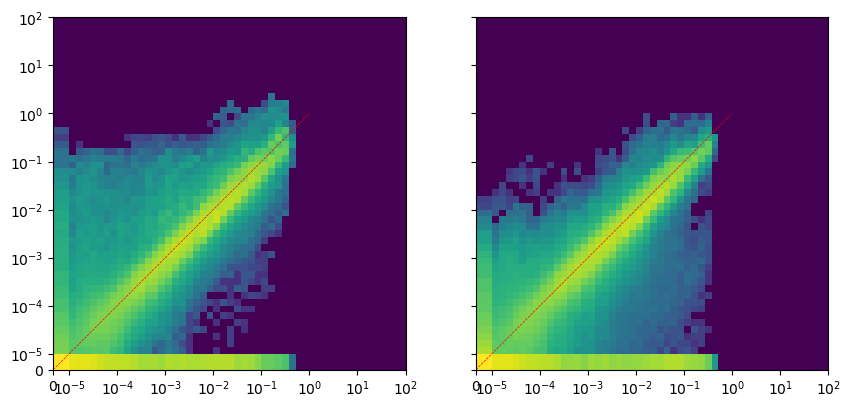

In [42]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))


thresh = '0_identical'

d = estimate_result
x = d.sel(tool='expect', thresh=thresh).to_series()



bins = [0] + list(np.logspace(-5, 2))


for ax, tool in zip(axs, ['megahit', 'strainzip']):
    y = d.sel(tool=tool, thresh=thresh).to_series()
    print(tool, sp.stats.spearmanr(x, y), sp.stats.pearsonr(x, y))
    ax.hist2d(x, y, bins=bins, norm=mpl.colors.SymLogNorm(1, vmin=1e-1, vmax=1e6))
    ax.set_xscale('symlog', linthresh=1e-5, linscale=0.3)
    ax.set_yscale('symlog', linthresh=1e-5, linscale=0.3)
    ax.set_aspect(1)
    ax.plot([0, 1], [0, 1], color='r', linestyle='--', lw=0.5)

# QUAST

In [43]:
genome_coverage = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Genome_fraction.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "genome_percent"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            genome_fraction=lambda x: x.genome_percent / 100,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_coverage.append(d)

genome_coverage = pd.concat(genome_coverage).set_index(['genome_id', 'tool', 'min_identity']).genome_fraction
genome_coverage.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Acidaminococcus_fermentans_DSM_20731_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           0.98436   0.99686   
0.990                                           0.98337   0.99655   
0.995                                           0.98298   0.99578   
0.999                                           0.97663   0.98618   
1.000                                           0.87916   0.85196   

genome_id    Acidaminococcus_intestini_D21_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                    0.98045   1.00000   
0.990                                    0.97868   0.99999   
0.995                                    0.97666   0.99783   
0.999                                    0.96754   0.34038   
1.000                                    0.84050   0.34043   

genome_id    Adlercreutzia_equolifaciens_DSM_19450_NCBI            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           0.99213   0.99394   
0.990                                           0.99191   0.99373   
0.995                                           0.99113   0.99306   
0.999                                           0.97255   0.97198   
1.000                                           0.28946   0.29806   

genome_id    Akkermansia_muciniphila_ATCC_BAA_835_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           0.98580   0.98918   
0.990                                           0.98563   0.98918   
0.995                                           0.98533   0.98889   
0.999                                           0.98165   0.97721   
1.000                                           0.40457   0.41515   

genome_id    Alistipes_finegoldii_DSM_17242_NCBI            ...  \
tool                                     megahit strainzip  ...   
min_identity                                                ...   
0.980                                    0.94999   0.98760  ...   
0.990                                    0.94775   0.98587  ...   
0.995                                    0.93224   0.97228  ...   
0.999                                    0.91128   0.91998  ...   
1.000                                    0.81064   0.58600  ...   

genome_id    Turicibacter_sanguinis_DSM_14220_MAF_2            \
tool                                        megahit strainzip   
min_identity                                                    
0.980                                       0.00007   0.00011   
0.990                                       0.00003   0.00000   
0.995                                       0.00000   0.00000   
0.999                                       0.00000   0.00008   
1.000                                       0.00000   0.00008   

genome_id    Tyzzerella_nexilis_DSM_1787_MAF_2            \
tool                                   megahit strainzip   
min_identity                                               
0.980                                  0.94289   0.98753   
0.990                                  0.93655   0.98157   
0.995                                  0.92393   0.95203   
0.999                                  0.89688   0.85440   
1.000                                  0.79087   0.56460   

genome_id    Veillonella_dispar_ATCC_17748_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                    0.96751   0.98922   
0.990                                    0.96412   0.9845

In [201]:
# WORKHERE: Add sequencing depth information for each genome and size the points based on that.

# Only consider genomes where the species has multiple strains.
genome_id_list = idxwhere(genome_details.species_id.isin(idxwhere(genome_details.species_id.value_counts().drop('UNKNOWN') > 1))).to_series().str.replace('-', '_').values

min_identity = 1.0

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))
d0 = genome_coverage.xs(min_identity, level='min_identity').unstack().assign(mean_rabund=_mean_rabund)

d0.drop(genome_id_list).to_csv('fig/quast_genome_coverage_id100_hcom2_singlestrain.tsv', sep='\t')
d0.loc[genome_id_list].to_csv('fig/quast_genome_coverage_id100_hcom2_multistrain.tsv', sep='\t')

0.656 0.01879


Text(0.5, 1.0, 'Un-covered Genome Length')

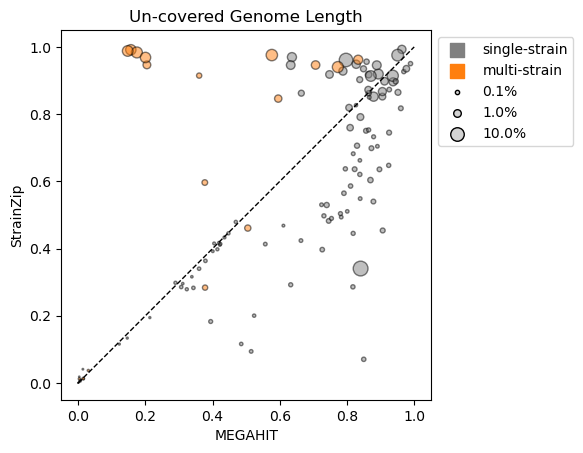

In [184]:
def _rabund_to_size(x):
    return np.sqrt(x) * 300

d = d0.assign(s=d0.mean_rabund.pipe(_rabund_to_size))

x = d['megahit']
y = d['strainzip']

print((y < x).mean(), (x - y).median())


fig, ax = plt.subplots()
ax.scatter('megahit', 'strainzip', data=d.drop(genome_id_list), color='grey', edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
ax.scatter('megahit', 'strainzip', data=d.loc[genome_id_list], color='tab:orange', edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
ax.set_aspect(1)
ax.set_xlabel('MEGAHIT')
ax.set_ylabel('StrainZip')

ax.scatter([], [], color='grey', marker='s', label='single-strain', s=100)
ax.scatter([], [], color='tab:orange', marker='s', label='multi-strain', s=100)
for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='lightgrey', edgecolor='k', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title('Un-covered Genome Length')

(array([ 1.,  2.,  8., 28., 61., 12.,  6.,  1.,  1.,  5.]),
 array([-0.77954 , -0.617527, -0.455514, -0.293501, -0.131488,  0.030525,
         0.192538,  0.354551,  0.516564,  0.678577,  0.84059 ]),
 <BarContainer object of 10 artists>)

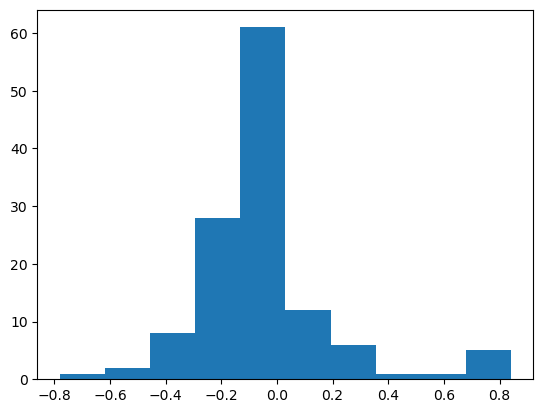

In [45]:
bins = np.linspace(-1, 1)
plt.hist(y - x)

In [46]:
genome_nga50 = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/NGA50.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "nga50"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_nga50.append(d)

genome_nga50 = pd.concat(genome_nga50).set_index(['genome_id', 'tool', 'min_identity']).nga50
genome_nga50.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Acidaminococcus_fermentans_DSM_20731_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           62457.0   98294.0   
0.990                                           62457.0   98294.0   
0.995                                           62457.0   98294.0   
0.999                                           62457.0   98294.0   
1.000                                           57121.0   97461.0   

genome_id    Acidaminococcus_intestini_D21_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                    56240.0     888.0   
0.990                                    56240.0     887.0   
0.995                                    56240.0     593.0   
0.999                                    56240.0     216.0   
1.000                                    53760.0     216.0   

genome_id    Adlercreutzia_equolifaciens_DSM_19450_NCBI            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           12961.0   23127.0   
0.990                                           12961.0   23127.0   
0.995                                           12961.0   23127.0   
0.999                                           12961.0   23127.0   
1.000                                               0.0    3147.0   

genome_id    Akkermansia_muciniphila_ATCC_BAA_835_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                           18977.0   29975.0   
0.990                                           18977.0   29975.0   
0.995                                           18977.0   29975.0   
0.999                                           18977.0   29975.0   
1.000                                               0.0   13504.0   

genome_id    Alistipes_finegoldii_DSM_17242_NCBI            ...  \
tool                                     megahit strainzip  ...   
min_identity                                                ...   
0.980                                    42472.0  338759.0  ...   
0.990                                    42472.0  338759.0  ...   
0.995                                    42472.0  338759.0  ...   
0.999                                    42472.0  338759.0  ...   
1.000                                    36996.0  335810.0  ...   

genome_id    Turicibacter_sanguinis_DSM_14220_MAF_2            \
tool                                        megahit strainzip   
min_identity                                                    
0.980                                           0.0       0.0   
0.990                                           0.0       0.0   
0.995                                           0.0       0.0   
0.999                                           0.0       0.0   
1.000                                           0.0       0.0   

genome_id    Tyzzerella_nexilis_DSM_1787_MAF_2            \
tool                                   megahit strainzip   
min_identity                                               
0.980                                  48343.0  115529.0   
0.990                                  48343.0  115529.0   
0.995                                  48343.0  115529.0   
0.999                                  48343.0  115529.0   
1.000                                  40572.0  113527.0   

genome_id    Veillonella_dispar_ATCC_17748_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                    20718.0  105663.0   
0.990                                    20718.0  105663.

0.816 67290.0


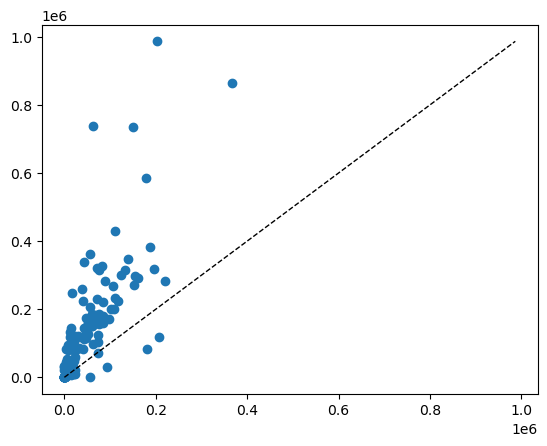

In [187]:
min_identity = 0.98
d = genome_nga50.to_xarray().sel(min_identity=min_identity)

x = d.sel(tool='megahit')
y = d.sel(tool='strainzip')

print((y > x).mean().values, (y - x).median().values)

plt.scatter(x, y)
plt.plot([0, d.max()], [0, d.max()], lw=1, linestyle='--', color='k')

In [48]:
genome_duplication_ratio = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Duplication_ratio.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "duplication_ratio"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_duplication_ratio.append(d)

genome_duplication_ratio = pd.concat(genome_duplication_ratio).set_index(['genome_id', 'tool', 'min_identity']).duplication_ratio
genome_duplication_ratio.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Acidaminococcus_fermentans_DSM_20731_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                             1.006     5.594   
0.990                                             1.005     5.572   
0.995                                             1.004     5.535   
0.999                                             1.004     5.525   
1.000                                             1.003     3.319   

genome_id    Acidaminococcus_intestini_D21_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                      1.023    29.386   
0.990                                      1.020    29.348   
0.995                                      1.015    16.810   
0.999                                      1.013     2.645   
1.000                                      1.013     2.646   

genome_id    Adlercreutzia_equolifaciens_DSM_19450_NCBI            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                             1.003     2.009   
0.990                                             1.003     2.006   
0.995                                             1.003     2.003   
0.999                                             1.002     2.003   
1.000                                             1.003     2.006   

genome_id    Akkermansia_muciniphila_ATCC_BAA_835_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                             1.002     2.022   
0.990                                             1.002     2.022   
0.995                                             1.002     2.021   
0.999                                             1.002     2.018   
1.000                                             1.002     2.008   

genome_id    Alistipes_finegoldii_DSM_17242_NCBI            ...  \
tool                                     megahit strainzip  ...   
min_identity                                                ...   
0.980                                      1.016     6.573  ...   
0.990                                      1.013     6.502  ...   
0.995                                      1.010     6.408  ...   
0.999                                      1.006     6.129  ...   
1.000                                      1.007     4.731  ...   

genome_id    Turicibacter_sanguinis_DSM_14220_MAF_2            \
tool                                        megahit strainzip   
min_identity                                                    
0.980                                          3.48     6.342   
0.990                                          1.00     0.000   
0.995                                          0.00     0.000   
0.999                                          0.00    22.059   
1.000                                          0.00    22.059   

genome_id    Tyzzerella_nexilis_DSM_1787_MAF_2            \
tool                                   megahit strainzip   
min_identity                                               
0.980                                    1.029     4.828   
0.990                                    1.022     4.649   
0.995                                    1.015     4.432   
0.999                                    1.011     4.152   
1.000                                    1.010     3.086   

genome_id    Veillonella_dispar_ATCC_17748_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                      1.013     3.071   
0.990                                      1.010     3.05

In [49]:
genome_num_misassemblies = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/num_misassemblies.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "num_misassemblies"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_num_misassemblies.append(d)

genome_num_misassemblies = pd.concat(genome_num_misassemblies).set_index(['genome_id', 'tool', 'min_identity']).num_misassemblies
genome_num_misassemblies.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Acidaminococcus_fermentans_DSM_20731_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                               4.0      38.0   
0.990                                               4.0      38.0   
0.995                                               3.0      34.0   
0.999                                               3.0      35.0   
1.000                                               2.0       3.0   

genome_id    Acidaminococcus_intestini_D21_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                       10.0      65.0   
0.990                                        5.0      51.0   
0.995                                        3.0      33.0   
0.999                                        3.0      22.0   
1.000                                        2.0      22.0   

genome_id    Adlercreutzia_equolifaciens_DSM_19450_NCBI            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                               4.0      13.0   
0.990                                               4.0      13.0   
0.995                                               2.0       9.0   
0.999                                               2.0       7.0   
1.000                                               1.0       3.0   

genome_id    Akkermansia_muciniphila_ATCC_BAA_835_MAF_2            \
tool                                            megahit strainzip   
min_identity                                                        
0.980                                               2.0      18.0   
0.990                                               2.0      18.0   
0.995                                               2.0      18.0   
0.999                                               2.0      12.0   
1.000                                               2.0       4.0   

genome_id    Alistipes_finegoldii_DSM_17242_NCBI            ...  \
tool                                     megahit strainzip  ...   
min_identity                                                ...   
0.980                                        7.0     170.0  ...   
0.990                                        7.0     144.0  ...   
0.995                                        7.0     131.0  ...   
0.999                                        5.0     103.0  ...   
1.000                                        4.0      35.0  ...   

genome_id    Turicibacter_sanguinis_DSM_14220_MAF_2            \
tool                                        megahit strainzip   
min_identity                                                    
0.980                                           0.0       0.0   
0.990                                           0.0       0.0   
0.995                                           0.0       0.0   
0.999                                           0.0       0.0   
1.000                                           0.0       0.0   

genome_id    Tyzzerella_nexilis_DSM_1787_MAF_2            \
tool                                   megahit strainzip   
min_identity                                               
0.980                                      7.0     268.0   
0.990                                      8.0     215.0   
0.995                                      9.0     197.0   
0.999                                      7.0     113.0   
1.000                                      5.0      26.0   

genome_id    Veillonella_dispar_ATCC_17748_MAF_2            \
tool                                     megahit strainzip   
min_identity                                                 
0.980                                        1.0      44.0   
0.990                                        2.0      42.

# Fraction of Reads Mapping to Erroneous Sequences

### MEGAHIT

In [50]:
megahit_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[0-1389]+       1389
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[1636-2764]+    1128
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[2763-3900]+    1137
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[3896-4628]+     732
Acidaminococcus-fermentans-DSM-20731_MAF-2_1[4605-4833]+     228
                                                            ... 
Veillonella-sp-6-1-27_MAF-2_1[2178221-2179019]-              798
Veillonella-sp-6-1-27_MAF-2_1[2179028-2179694]-              666
Veillonella-sp-6-1-27_MAF-2_1[2179856-2180078]-              222
Veillonella-sp-6-1-27_MAF-2_1[2180126-2180492]-              366
Veillonella-sp-6-1-27_MAF-2_1[2180565-2180700]-              135
Name: nlength, Length: 410946, dtype: int64

In [51]:
megahit_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(megahit_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

megahit_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,k111_7656,Bacteroides-sp-2-1-22_MinIONHybrid_1,99.990,41802,4,0,1,41802,738478,780279,0.000000e+00,77172.0,41802,0.99990,1.000000,0,738477,41802,780279,Bacteroides-sp-2-1-22_MinIONHybrid_1
1,k111_7656,Bacteroides-sp-2-1-22_MinIONHybrid_1,95.252,337,14,2,35162,35496,3482431,3482095,7.160000e-148,532.0,41802,0.95252,0.008062,35161,3482430,35496,3482095,Bacteroides-sp-2-1-22_MinIONHybrid_1
2,k111_7656,Bacteroides-sp-2-1-22_MinIONHybrid_1,93.623,345,21,1,35153,35496,2865992,2866336,2.590000e-142,514.0,41802,0.93623,0.008253,35152,2865991,35496,2866336,Bacteroides-sp-2-1-22_MinIONHybrid_1
3,k111_7656,Bacteroides-sp-2-1-22_MinIONHybrid_1,93.372,347,21,2,35153,35497,1124052,1124398,9.320000e-142,512.0,41802,0.93372,0.008301,35152,1124051,35497,1124398,Bacteroides-sp-2-1-22_MinIONHybrid_1
4,k111_7656,Bacteroides-sp-2-1-22_MinIONHybrid_1,95.484,310,14,0,34865,35174,2865660,2865969,9.390000e-137,496.0,41802,0.95484,0.007416,34864,2865659,35174,2865969,Bacteroides-sp-2-1-22_MinIONHybrid_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820198,k111_47324,Alistipes-onderdonkii-DSM-19147_MAF-2_1,77.285,1488,297,35,3246,4714,452555,454020,0.000000e+00,837.0,7112,0.77285,0.209224,3245,452554,4714,454020,Alistipes-onderdonkii-DSM-19147_MAF-2_1
1820199,k111_47324,Alistipes-onderdonkii-DSM-19147_MAF-2_1,78.316,1033,186,31,6101,7109,457035,458053,1.160000e-178,632.0,7112,0.78316,0.145247,6100,457034,7109,458053,Alistipes-onderdonkii-DSM-19147_MAF-2_1
1820200,k111_47324,Alistipes-onderdonkii-DSM-19147_MAF-2_1,75.658,1368,260,55,1662,2995,450910,452238,4.210000e-173,614.0,7112,0.75658,0.192351,1661,450909,2995,452238,Alistipes-onderdonkii-DSM-19147_MAF-2_1
1820201,k111_47324,Alistipes-putredinis-DSM-17216_MAF-2_1,81.102,1434,240,23,1,1417,727108,728527,0.000000e+00,1118.0,7112,0.81102,0.201631,0,727107,1417,728527,Alistipes-putredinis-DSM-17216_MAF-2_1


In [52]:
megahit_aligned_bases = (megahit_contig_depth.T * megahit_sequence_length).sum(1)
megahit_missaligned_bases = (
    megahit_contig_depth.T.drop(
        columns=megahit_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * megahit_sequence_length
).sum(1)
megahit_well_aligned_frac = 1 - (megahit_missaligned_bases / megahit_aligned_bases)
megahit_well_aligned_frac

sample
xjin_AB_P0R1a             0.677939
xjin_AB_P0R2a             0.683630
xjin_AB_P1R1a             0.654364
xjin_AB_P1R2a             0.646804
xjin_AB_P2R1a             0.670454
                            ...   
xjin_N_P4R2a              0.721536
xjin_N_P5R1a              0.727340
xjin_N_P5R2a              0.734055
xjin_XT_Innoculum_Rep1    0.765493
xjin_XT_Innoculum_Rep2    0.765282
Length: 66, dtype: float64

### StrainZip

In [53]:
strainzip_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
strainzip_sequence_length

gene
675771    1972504
677423    1972252
664933    1308561
660847    1288922
727669    1061918
           ...   
137251        111
53788         111
137246        111
53789         111
0             111
Name: nlength, Length: 727961, dtype: int64

In [54]:
strainzip_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(strainzip_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

strainzip_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,677423,Anaerostipes-caccae-DSM-14662_MAF-2_1,99.998,564045,9,1,1,564045,1977463,2541506,0.000000e+00,1042000.0,1972252,0.99998,0.285990,0,1977462,564045,2541506,Anaerostipes-caccae-DSM-14662_MAF-2_1
1,677423,Anaerostipes-caccae-DSM-14662_MAF-2_1,99.998,564045,9,1,1408208,1972252,2541506,1977463,0.000000e+00,1042000.0,1972252,0.99998,0.285990,1408207,2541505,1972252,1977463,Anaerostipes-caccae-DSM-14662_MAF-2_1
2,677423,Anaerostipes-caccae-DSM-14662_MAF-2_1,99.990,422838,41,0,563677,986514,2541264,2964101,0.000000e+00,780600.0,1972252,0.99990,0.214393,563676,2541263,986514,2964101,Anaerostipes-caccae-DSM-14662_MAF-2_1
3,677423,Anaerostipes-caccae-DSM-14662_MAF-2_1,99.988,422324,48,1,986253,1408576,2963586,2541264,0.000000e+00,779600.0,1972252,0.99988,0.214133,986252,2963585,1408576,2541264,Anaerostipes-caccae-DSM-14662_MAF-2_1
4,677423,Anaerostipes-caccae-DSM-14662_MAF-2_1,90.692,3105,265,18,759653,762745,2125088,2128180,0.000000e+00,4111.0,1972252,0.90692,0.001574,759652,2125087,762745,2128180,Anaerostipes-caccae-DSM-14662_MAF-2_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17900205,41262,Mitsuokella-multacida-DSM-20544_MAF-2_2,100.000,111,0,0,1,111,27529,27419,3.650000e-52,206.0,111,1.00000,1.000000,0,27528,111,27419,Mitsuokella-multacida-DSM-20544_MAF-2_2
17900206,41262,Mitsuokella-multacida-DSM-20544_MAF-2_1,100.000,111,0,0,1,111,8222,8112,3.650000e-52,206.0,111,1.00000,1.000000,0,8221,111,8112,Mitsuokella-multacida-DSM-20544_MAF-2_1
17900207,41262,Mitsuokella-multacida-DSM-20544_MAF-2_1,100.000,111,0,0,1,111,641630,641740,3.650000e-52,206.0,111,1.00000,1.000000,0,641629,111,641740,Mitsuokella-multacida-DSM-20544_MAF-2_1
17900208,159679,Acidaminococcus-intestini-D21_MAF-2_1,100.000,111,0,0,1,111,1757750,1757860,3.650000e-52,206.0,111,1.00000,1.000000,0,1757749,111,1757860,Acidaminococcus-intestini-D21_MAF-2_1


In [55]:
strainzip_aligned_kmers = (vertex_depth.T * strainzip_sequence_length).sum(1)
strainzip_missaligned_kmers = (
    vertex_depth.T.drop(
        columns=strainzip_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * strainzip_sequence_length
).sum(1)
strainzip_well_aligned_frac = 1 - (
    strainzip_missaligned_kmers / strainzip_aligned_kmers
)
strainzip_well_aligned_frac

sample
xjin_Flex_Innoculum_Rep1    0.691649
xjin_KAPA_Innoculum_Rep1    0.674650
xjin_XT_Innoculum_Rep1      0.616273
xjin_AB_P0R1a               0.913457
xjin_AS_P0R1a               0.908682
                              ...   
xjin_AB_P5R2a               0.961540
xjin_AS_P5R2a               0.953740
xjin_MB_P5R2a               0.950261
xjin_MS_P5R2a               0.942433
xjin_N_P5R2a                0.975788
Length: 66, dtype: float64

### Combined

In [56]:
missaligned = []

for tool_name, match, weight, length in [
    (
        "strainzip",
        strainzip_to_ref.assign(key=lambda x: x.vertex),
        vertex_depth.T * strainzip_sequence_length,
        strainzip_sequence_length,
    ),
    (
        "megahit",
        megahit_to_ref.assign(key=lambda x: x.vertex),
        megahit_contig_depth.T * megahit_sequence_length,
        megahit_sequence_length,
    ),
]:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )
        missaligned_weight = (
            weight.drop(
                columns=match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum(1)
        missaligned_length = (
            length.drop(
                match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum()

        for sample in missaligned_weight.index:
            missaligned.append(
                dict(
                    sample=sample,
                    thresh=thresh_name,
                    min_coverage=_min_coverage,
                    min_identity=_min_identity,
                    tool=tool_name,
                    missaligned_weight_frac=missaligned_weight.loc[sample]
                    / weight.loc[sample].sum(),
                    missaligned_length_frac=missaligned_length / length.sum(),
                )
            )

missaligned = pd.DataFrame(missaligned)

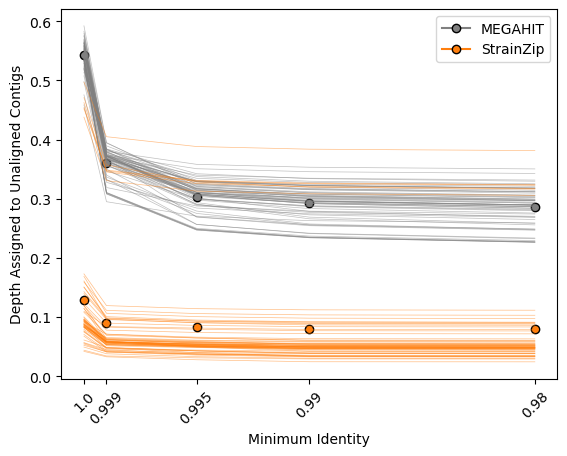

In [224]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_weight_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                # linestyle=linestyle_palette[tool],
                lw=0.5,
                color={'strainzip': 'tab:orange', 'megahit': 'grey'}[tool],
                # marker="o",
                # markerfacecolor=facecolor_palette[tool],
                alpha=0.5,
            )
        plt.scatter(
            d2.columns,
            d2.mean(0),
            # color="k",
            # lw=3,
            # linestyle=linestyle_palette[tool],
            # markerfacecolor=facecolor_palette[tool],
            marker="o",
            edgecolor='k',
            color={'strainzip': 'tab:orange', 'megahit': 'grey'}[tool],
            # label=tool,
        )

plt.plot([], [], marker='o', markeredgecolor='k', color='grey', label='MEGAHIT')
plt.plot([], [], marker='o', markeredgecolor='k', color='tab:orange', label='StrainZip')

plt.xticks(d3.index, d3.index, rotation=45)

plt.ylabel("Depth Assigned to Unaligned Contigs")
plt.xlabel("Minimum Identity")
plt.legend()
plt.gca().invert_xaxis()

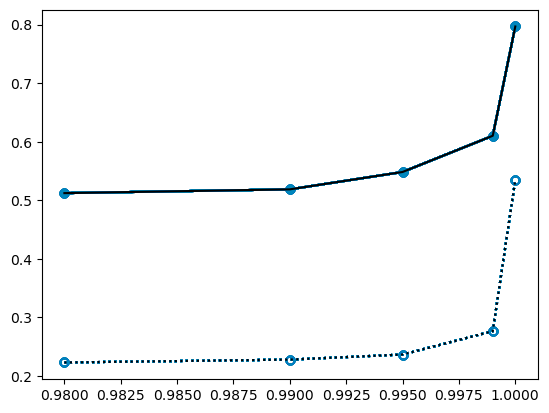

In [58]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_length_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                linestyle=linestyle_palette[tool],
                c=sample_palette[sample],
                marker="o",
                markerfacecolor=facecolor_palette[tool],
            )
        plt.plot(
            d2.mean(0),
            color="k",
            linestyle=linestyle_palette[tool],
            markerfacecolor=facecolor_palette[tool],
        )

In [218]:
d = missaligned.set_index(['sample', 'thresh', '
d

,sample,thresh,min_coverage,min_identity,tool,missaligned_weight_frac,missaligned_length_frac
0,xjin_Flex_Innoculum_Rep1,0_identical,1.0,1.0,strainzip,0.437867,0.796691
1,xjin_KAPA_Innoculum_Rep1,0_identical,1.0,1.0,strainzip,0.451905,0.796691
2,xjin_XT_Innoculum_Rep1,0_identical,1.0,1.0,strainzip,0.497014,0.796691
3,xjin_AB_P0R1a,0_identical,1.0,1.0,strainzip,0.160840,0.796691
4,xjin_AS_P0R1a,0_identical,1.0,1.0,strainzip,0.142731,0.796691
...,...,...,...,...,...,...,...
391,xjin_N_P4R2a,0_identical,1.0,1.0,megahit,0.563179,0.534742
392,xjin_N_P5R1a,0_identical,1.0,1.0,megahit,0.547234,0.534742
393,xjin_N_P5R2a,0_identical,1.0,1.0,megahit,0.558106,0.534742
394,xjin_XT_Innoculum_Rep1,0_identical,1.0,1.0,megahit,0.535165,0.534742
